# 1. Read JSON

In [5]:
import ijson
import sys

file_path = './datasets/db2024-12-17.json'

# Read JSON file in chunks using ijson
with open(file_path, 'r') as file:
    for chunk in ijson.items(file,'model.item'):  # Replace 'item' with the root element of your JSON
        print(chunk)

In [13]:
import json
import sys

file_path = './datasets/db2024-12-17.json'
json_list = []

# Read JSON file in chunks using ijson
with open(file_path, 'r') as json_file:
    json_list = json.load(json_file)

model_names = set()
for item in json_list:
    model_names.add(item['model'])

print(model_names)

{'base.leaveapplication', 'base.attendance', 'base.address', 'base.establishment', 'base.company', 'base.leadership', 'base.transfer', 'base.postinglocation', 'base.payscale', 'base.promotion', 'base.nextofkin', 'base.qualification', 'base.leaveinventory', 'base.awardlevel', 'base.user', 'base.hgcd', 'base.leavetracker', 'base.relation', 'base.designation', 'base.rank', 'base.disciplinaryactionlevel', 'base.attendancedetail', 'base.posting'}


# 2. Save JSON to CSV

In [14]:
# ('base.leaveapplication')
leave_applications = []
for item in json_list:
    if item['model'] == 'base.leaveapplication':
        leave_applications.append(item)

In [15]:
# with open("./datasets/leave.json", "w") as file:
#     for leave in leave_applications:
#         file.write(f"{leave}\n")

import json
with open("./datasets/leave.json", 'w', encoding='utf-8') as f:
    json.dump(leave_applications, f, ensure_ascii=False, indent=4)

In [1]:
import pandas as pd
import json

file_path = "./datasets/leave.json"

# The JSON has three keys: model, pk, fields
# json_normalize() to extract information from the fields column
# and merge with model and pk columns 
leave_df = pd.read_json(file_path)
fields_df = pd.json_normalize(leave_df['fields'])

leave_df = pd.merge(leave_df, fields_df, left_index=True, right_index=True)
leave_df = leave_df.drop('fields', axis = 1)

leave_df

,model,pk,submitter,address,applicant,recommend_1,recommend_2,approve,submitted_on,start,end,days,updated,added,type,status
0,base.leaveapplication,42,[dba2],"Chaltlang, Aizawl",[hg614],[hg165],[ocb],[distc],2023-10-05T12:14:24.343,2023-10-05T00:00:00,2023-10-15T00:00:00,11,2023-10-05T12:14:24.343,2023-10-05T12:14:24.343,9,6
1,base.leaveapplication,43,[dba2],Champhai,[hg974],[hg165],[ocb],[distc],2023-10-05T12:15:16.139,2023-10-06T00:00:00,2023-10-13T00:00:00,8,2023-10-05T12:15:16.139,2023-10-05T12:15:16.139,9,6
2,base.leaveapplication,44,[dba2],"Chiahpui, Champhai",[hg1344],[hg165],[ocb],[distc],2023-10-05T12:17:05.452,2023-10-04T00:00:00,2023-10-09T00:00:00,6,2023-10-05T12:17:05.452,2023-10-05T12:17:05.453,9,6
3,base.leaveapplication,45,[dba2],"Bethlehem, Aizawl",[hg296],[hg165],[ocb],[distc],2023-10-05T12:18:10.892,2023-10-04T00:00:00,2023-10-08T00:00:00,5,2023-10-05T12:18:10.892,2023-10-05T12:18:10.892,9,6
4,base.leaveapplication,46,[dba2],Thenzawl,[hg1329],[hg165],[ocb],[distc],2023-10-05T12:18:57.979,2023-10-04T00:00:00,2023-10-19T00:00:00,16,2023-10-05T12:18:57.980,2023-10-05T12:18:57.980,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3519,base.leaveapplication,3995,[hg1177],aizawl,[hg989],[hg165],[ocb],[distc],2024-12-16T10:45:58.976,2024-12-16T00:00:00,2024-12-20T00:00:00,5,2024-12-16T10:45:58.976,2024-12-16T10:45:58.976,9,6
3520,base.leaveapplication,3996,[hg1177],aizawl,[hg1384],[hg165],[ocb],[distc],2024-12-17T11:01:03.600,2024-12-18T00:00:00,2024-12-30T00:00:00,13,2024-12-17T11:01:03.600,2024-12-17T11:01:03.600,9,6
3521,base.leaveapplication,3997,[hg1177],aizawl,[hg1273],[hg165],[ocb],[distc],2024-12-17T11:05:47.842,2024-12-17T00:00:00,2024-12-23T00:00:00,7,2024-12-17T11:05:47.842,2024-12-17T11:05:47.842,9,6
3522,base.leaveapplication,3998,[dba2],Rangvamual,[hg1227],[hg193],[ocb],[distc],2024-12-17T11:08:00.249,2024-12-17T00:00:00,2024-12-18T00:00:00,2,2024-12-17T11:08:00.249,2024-12-17T11:08:00.249,9,6


In [4]:
import csv
leave_df.to_csv('./datasets/leave_df.csv', index=False, quoting=csv.QUOTE_ALL)

# 3. Exploratory Data Analysis

Types:
- OUTPASS = 1
- MATERNITY = 4
- PATERNITY = 5
- MEDICAL = 6
- SPECIAL = 9

Status:
- SUBMITTED=1
- RECOMMENDED_1=2
- NOT_RECOMMENDED_1=3
- RECOMMENDED_2=4
- NOT_RECOMMENDED_2=5
- APPROVED=6
- REJECTED =7

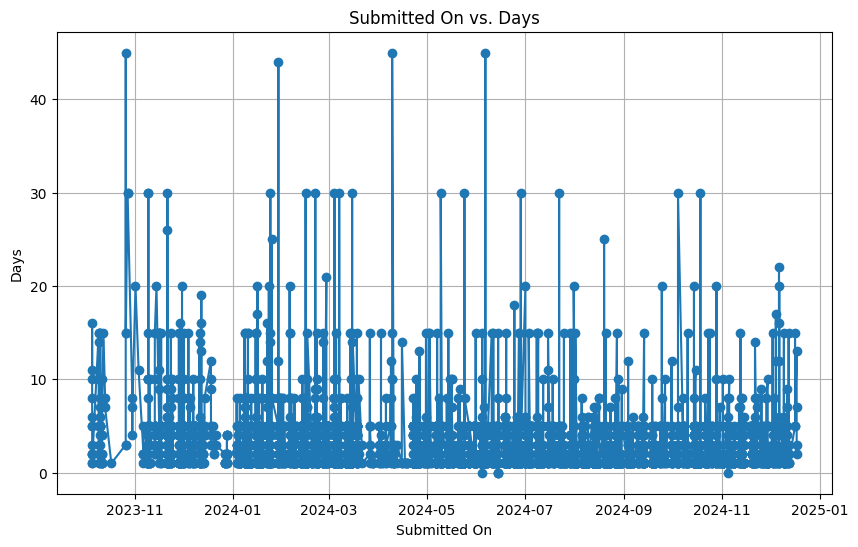

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file into a DataFrame
leave_df = pd.read_csv('./datasets/leave_df.csv')

# Convert the 'submitted_on' column to datetime if necessary
leave_df['submitted_on'] = pd.to_datetime(leave_df['submitted_on'])
leave_df['start'] = pd.to_datetime(leave_df['start'])
leave_df['end'] = pd.to_datetime(leave_df['end'])

# Set the 'submitted_on' column as the index
leave_df = leave_df.set_index('submitted_on')

# Convert the 'days' column to int if necessary
leave_df['days'] = leave_df['days'].astype(int)
leave_df['type'] = leave_df['type'].astype(int)
leave_df['status'] = leave_df['status'].astype(int)

# Plot 'submitted_on' vs. 'days'
plt.figure(figsize=(10, 6))
plt.plot(leave_df.index, leave_df['days'], marker='o')
plt.xlabel('Submitted On')
plt.ylabel('Days')
plt.title('Submitted On vs. Days')
plt.grid(True)
plt.show()

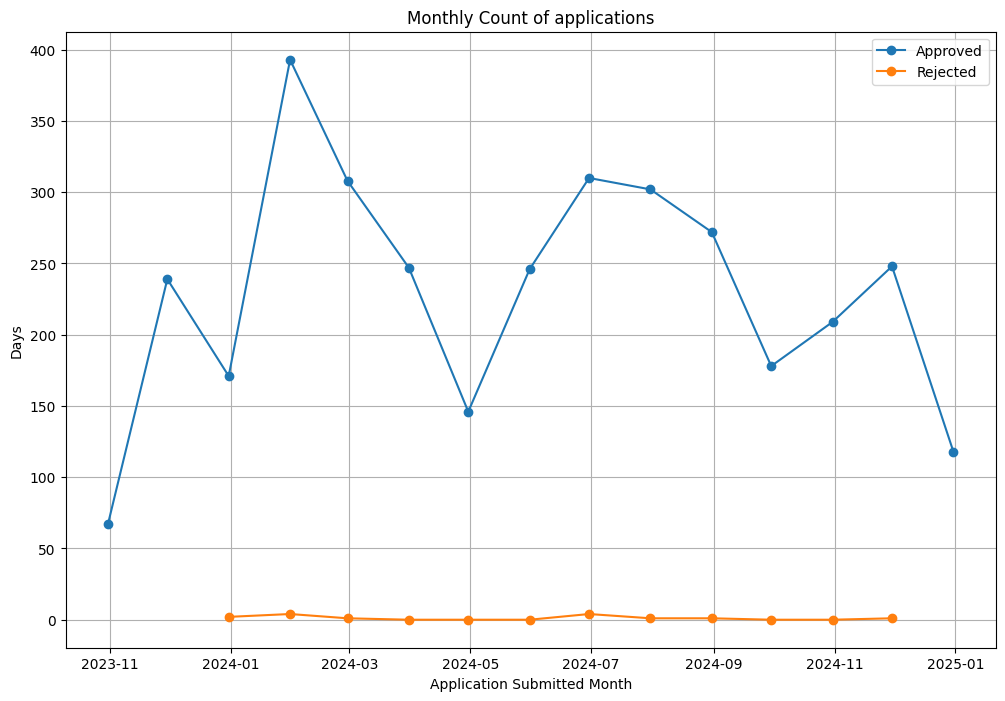

In [9]:
approved = leave_df[leave_df['status']==6].resample('ME').count()
rejected = leave_df[leave_df['status']==7].resample('ME').count()

# Plot the monthly mean, sum, and count
plt.figure(figsize=(12, 8))

plt.plot(approved.index, approved.status, marker='o', label='Approved')
plt.plot(rejected.index, rejected.status, marker='o', label='Rejected')

plt.xlabel('Application Submitted Month')
plt.ylabel('Days')
plt.title('Monthly Count of applications')
plt.legend()
plt.grid(True)
plt.show()

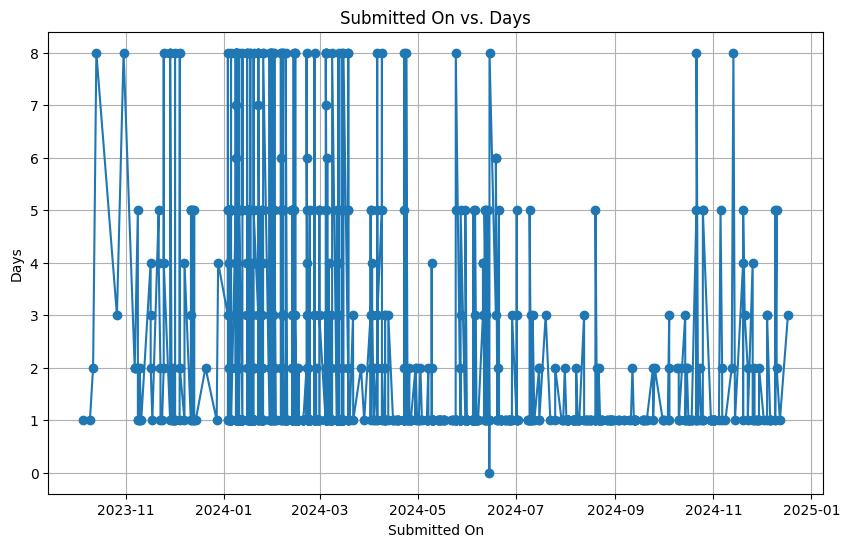

In [60]:
filtered_df = leave_df[leave_df['type'] == 1]

# Plot 'submitted_on' vs. 'days'
plt.figure(figsize=(10, 6))
plt.plot(filtered_df.index, filtered_df['days'], marker='o')
plt.xlabel('Submitted On')
plt.ylabel('Days')
plt.title('Submitted On vs. Days')
plt.grid(True)
plt.show()

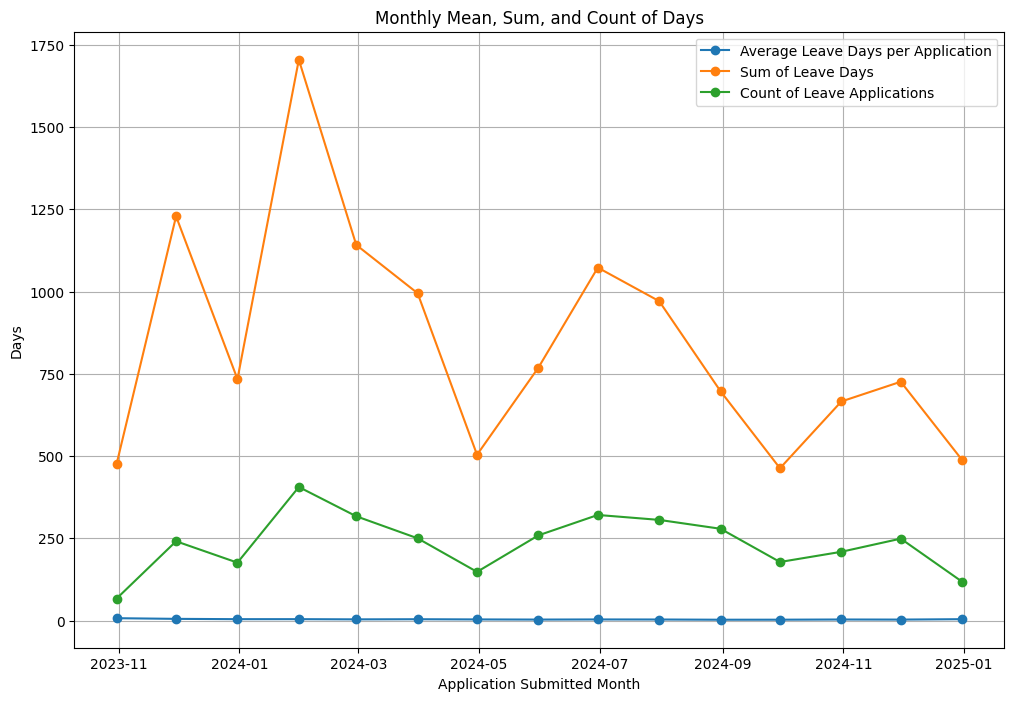

In [20]:
# Group by month and calculate mean, sum, and count
monthly_mean = leave_df['days'].resample('ME').mean()
monthly_sum = leave_df['days'].resample('ME').sum()
monthly_count = leave_df['days'].resample('ME').count()

# Plot the monthly mean, sum, and count
plt.figure(figsize=(12, 8))

plt.plot(monthly_mean.index, monthly_mean, marker='o', label='Average Leave Days per Application')
plt.plot(monthly_sum.index, monthly_sum, marker='o', label='Sum of Leave Days')
plt.plot(monthly_count.index, monthly_count, marker='o', label='Count of Leave Applications')

plt.xlabel('Application Submitted Month')
plt.ylabel('Days')
plt.title('Monthly Mean, Sum, and Count of Days')
plt.legend()
plt.grid(True)
plt.show()

# 4. Linear Regression

Mean Squared Error: 16.205440745723426


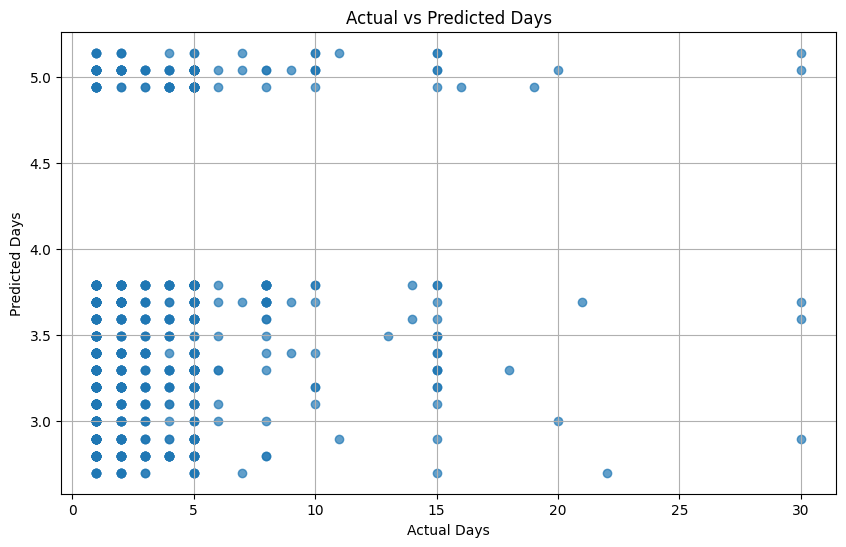

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Read the CSV file into a DataFrame
leave_df = pd.read_csv('./datasets/leave_df.csv')

# Convert the 'submitted_on' column to datetime
leave_df['submitted_on'] = pd.to_datetime(leave_df['submitted_on'])

# Extract features and target variable
leave_df['month'] = leave_df['submitted_on'].dt.month
leave_df['year'] = leave_df['submitted_on'].dt.year
X = leave_df[['year', 'month']]
y = leave_df['days']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict the days value
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Days')
plt.ylabel('Predicted Days')
plt.title('Actual vs Predicted Days')
plt.grid(True)
plt.show()

Mean MSE: 14.80399157639377
Standard Deviation of MSE: 3.8902162838614966
MSE on the entire dataset: 14.75641566972221


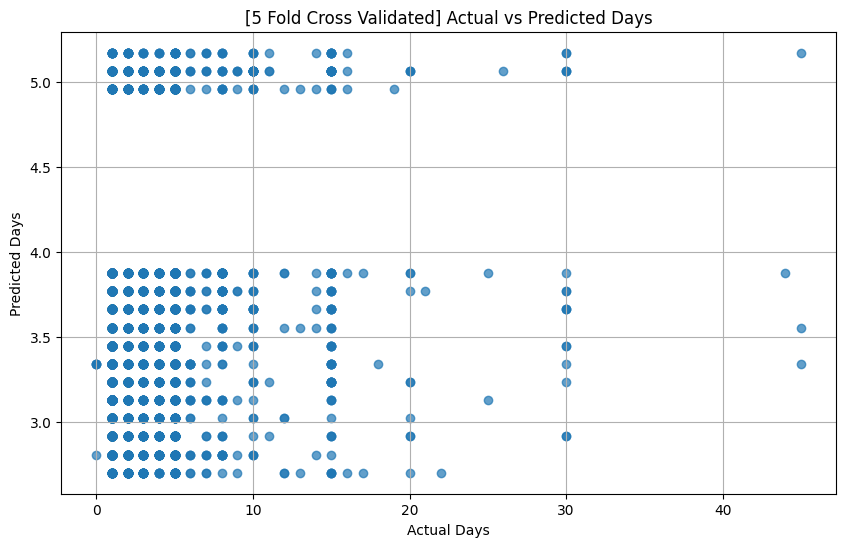

In [22]:
import pandas as pd
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Read the CSV file into a DataFrame
leave_df = pd.read_csv('./datasets/leave_df.csv')

# Convert the 'submitted_on' column to datetime
leave_df['submitted_on'] = pd.to_datetime(leave_df['submitted_on'])

# Extract features and target variable
leave_df['month'] = leave_df['submitted_on'].dt.month
leave_df['year'] = leave_df['submitted_on'].dt.year
X = leave_df[['year', 'month']]
y = leave_df['days']

# Initialize the linear regression model
model = LinearRegression()

# Perform cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

# Convert negative MSE to positive
cv_scores = -cv_scores

# Calculate the mean and standard deviation of the cross-validated MSE
mean_mse = cv_scores.mean()
std_mse = cv_scores.std()

print(f'Mean MSE: {mean_mse}')
print(f'Standard Deviation of MSE: {std_mse}')

# Train the model on the entire dataset
model.fit(X, y)

# Predict the days value
y_pred = model.predict(X)

# Evaluate the model on the entire dataset
mse = mean_squared_error(y, y_pred)
print(f'MSE on the entire dataset: {mse}')

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.7)
plt.xlabel('Actual Days')
plt.ylabel('Predicted Days')
plt.title('[5 Fold Cross Validated] Actual vs Predicted Days')
plt.grid(True)
plt.show()

# Spline

Mean Squared Error: 6313.1465599565945


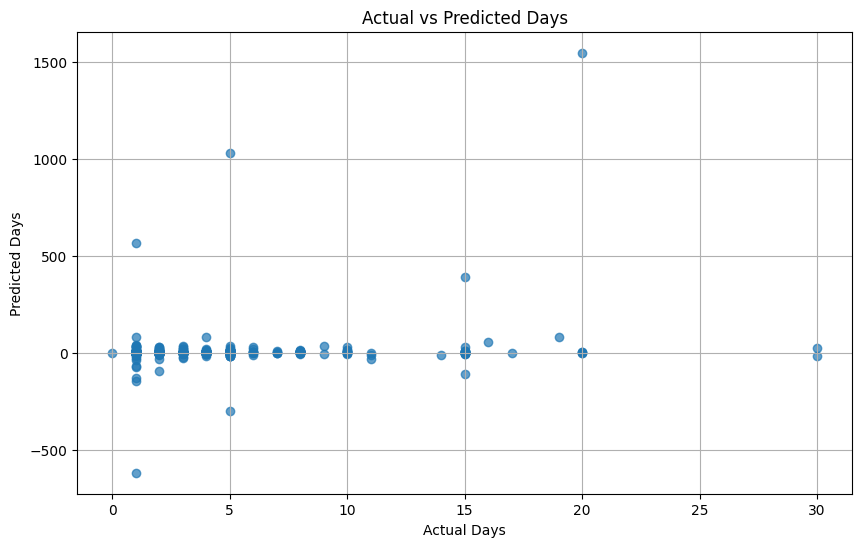

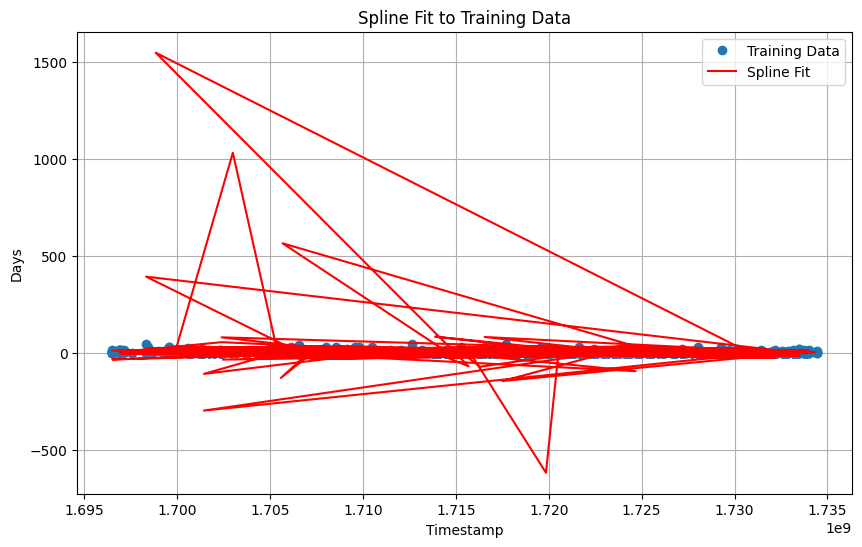

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from sklearn.model_selection import train_test_split

# Read the CSV file into a DataFrame
leave_df = pd.read_csv('./datasets/leave_df.csv')

# Convert the 'submitted_on' column to datetime
leave_df['submitted_on'] = pd.to_datetime(leave_df['submitted_on'])

# Extract features and target variable
leave_df['month'] = leave_df['submitted_on'].dt.month
leave_df['year'] = leave_df['submitted_on'].dt.year
leave_df['timestamp'] = leave_df['submitted_on'].astype(np.int64) // 10**9  # Convert datetime to timestamp
X = leave_df['timestamp']
y = leave_df['days']

# Sort the data by timestamp
sorted_indices = np.argsort(X)
X = X.iloc[sorted_indices]
y = y.iloc[sorted_indices]

# Remove duplicate timestamps by averaging the corresponding y-values
unique_X, indices = np.unique(X, return_index=True)
unique_y = [np.mean(y[X == ux]) for ux in unique_X]

# Convert to pandas Series for compatibility with train_test_split
unique_X = pd.Series(unique_X)
unique_y = pd.Series(unique_y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(unique_X, unique_y, test_size=0.2, random_state=42)

# Ensure the training data is strictly increasing
X_train, y_train = zip(*sorted(zip(X_train, y_train)))

# Fit a Univariate Spline model
spline = UnivariateSpline(X_train, y_train, s=0)

# Predict the days value
y_pred = spline(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = np.mean((y_test - y_pred) ** 2)
print(f'Mean Squared Error: {mse}')

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Days')
plt.ylabel('Predicted Days')
plt.title('Actual vs Predicted Days')
plt.grid(True)
plt.show()

# Plot the spline fit
plt.figure(figsize=(10, 6))
plt.plot(X_train, y_train, 'o', label='Training Data')
plt.plot(X_test, y_pred, 'r', label='Spline Fit')
plt.xlabel('Timestamp')
plt.ylabel('Days')
plt.title('Spline Fit to Training Data')
plt.legend()
plt.grid(True)
plt.show()

# Random Forest

Mean Squared Error: 16.01646631353163


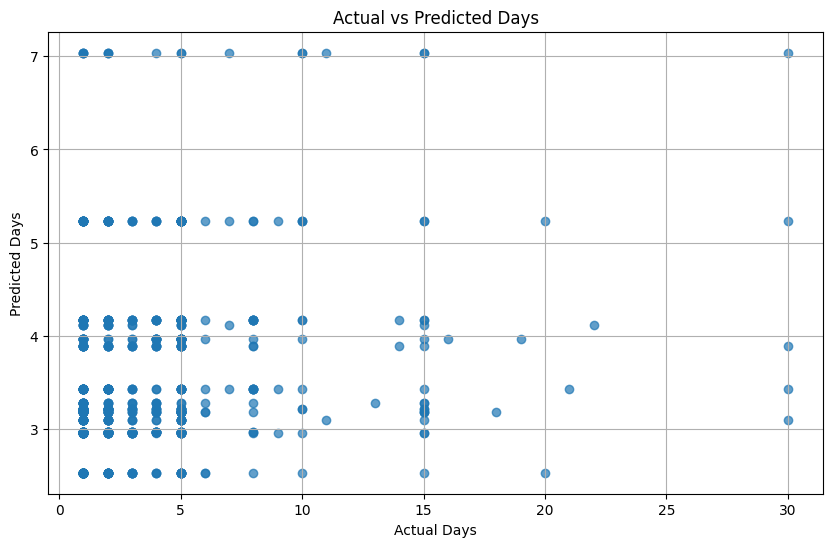

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Read the CSV file into a DataFrame
leave_df = pd.read_csv('./datasets/leave_df.csv')

# Convert the 'submitted_on' column to datetime
leave_df['submitted_on'] = pd.to_datetime(leave_df['submitted_on'])

# Extract features and target variable
leave_df['month'] = leave_df['submitted_on'].dt.month
leave_df['year'] = leave_df['submitted_on'].dt.year
X = leave_df[['year', 'month']]
y = leave_df['days']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict the days value
y_pred = model.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Days')
plt.ylabel('Predicted Days')
plt.title('Actual vs Predicted Days')
plt.grid(True)
plt.show()

# LSTM

Epoch [10/100], Loss: 27.7254
Epoch [20/100], Loss: 27.2992
Epoch [30/100], Loss: 26.7685
Epoch [40/100], Loss: 26.0391
Epoch [50/100], Loss: 24.9917
Epoch [60/100], Loss: 23.5116
Epoch [70/100], Loss: 21.5642
Epoch [80/100], Loss: 19.2954
Epoch [90/100], Loss: 17.0824
Epoch [100/100], Loss: 15.4180
Mean Squared Error on the test set: 17.5733


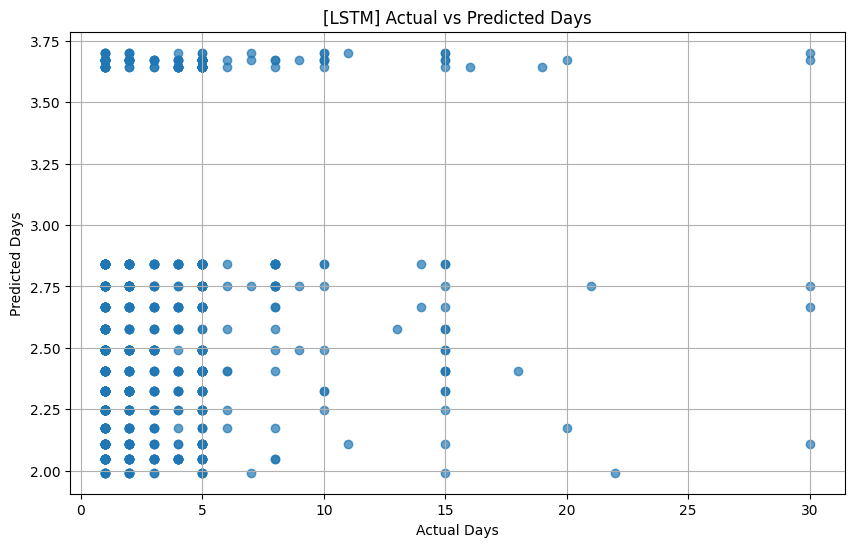

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Read the CSV file into a DataFrame
leave_df = pd.read_csv('./datasets/leave_df.csv')

# Convert the 'submitted_on' column to datetime
leave_df['submitted_on'] = pd.to_datetime(leave_df['submitted_on'])

# Extract features and target variable
leave_df['month'] = leave_df['submitted_on'].dt.month
leave_df['year'] = leave_df['submitted_on'].dt.year
X = leave_df[['year', 'month']]
y = leave_df['days']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# Hyperparameters
input_size = X_train_tensor.shape[1]
hidden_size = 50
num_layers = 2
output_size = 1
num_epochs = 100
learning_rate = 0.001

# Initialize the model, loss function, and optimizer
model = LSTMModel(input_size, hidden_size, num_layers, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Reshape input tensors for LSTM
X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)

# Train the model
for epoch in range(num_epochs):
    model.train()
    outputs = model(X_train_tensor)
    optimizer.zero_grad()
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    mse = criterion(y_pred, y_test_tensor).item()
    print(f'Mean Squared Error on the test set: {mse:.4f}')

# Plot the actual vs predicted values
y_pred = y_pred.numpy()
y_test = y_test_tensor.numpy()

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Days')
plt.ylabel('Predicted Days')
plt.title('[LSTM] Actual vs Predicted Days')
plt.grid(True)
plt.show()

# ARIMA

/home/peka/prototypes/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/peka/prototypes/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/peka/prototypes/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/peka/prototypes/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index b

Mean Squared Error: 11.047710867672098


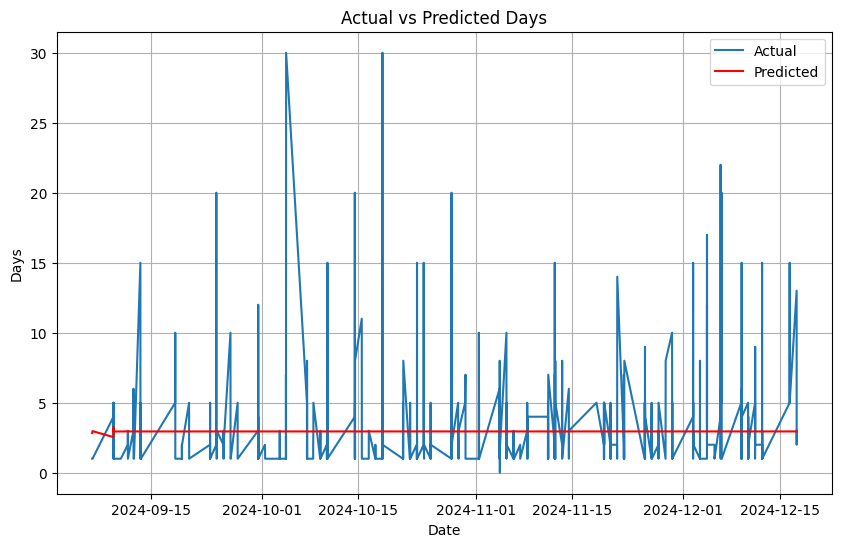

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Read the CSV file into a DataFrame
leave_df = pd.read_csv('./datasets/leave_df.csv')

# Convert the 'submitted_on' column to datetime
leave_df['submitted_on'] = pd.to_datetime(leave_df['submitted_on'])

# Set the 'submitted_on' column as the index
leave_df.set_index('submitted_on', inplace=True)

# Extract the target variable
y = leave_df['days']

# Split the data into training and testing sets
train_size = int(len(y) * 0.8)
train, test = y[:train_size], y[train_size:]

# Fit the ARIMA model
model = ARIMA(train, order=(5, 1, 0))  # You can adjust the order (p, d, q) as needed
model_fit = model.fit()

# Predict the days value
y_pred = model_fit.forecast(steps=len(test))

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(test, y_pred)
print(f'Mean Squared Error: {mse}')

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, y_pred, label='Predicted', color='red')
plt.xlabel('Date')
plt.ylabel('Days')
plt.title('Actual vs Predicted Days')
plt.legend()
plt.grid(True)
plt.show()

# Exponential Smoothing

/home/peka/prototypes/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/peka/prototypes/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/peka/prototypes/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Mean Squared Error: 11.37756680709963


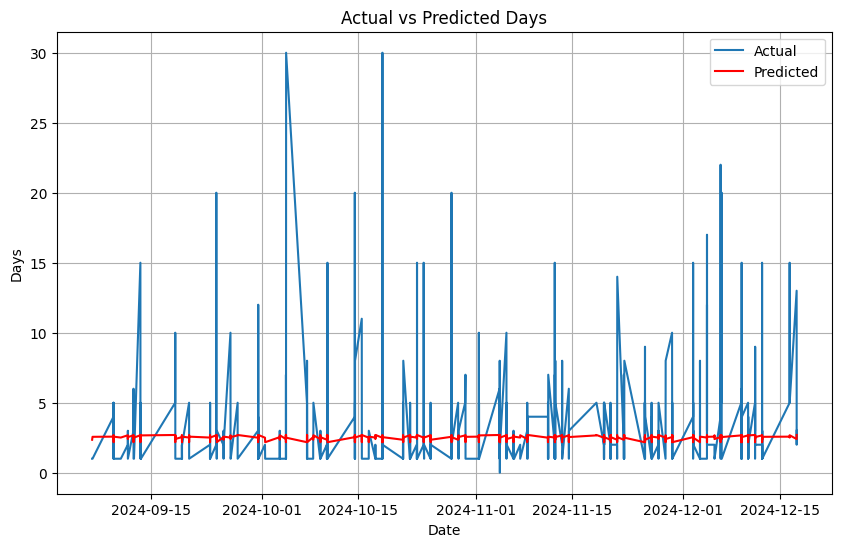

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

# Read the CSV file into a DataFrame
leave_df = pd.read_csv('./datasets/leave_df.csv')

# Convert the 'submitted_on' column to datetime
leave_df['submitted_on'] = pd.to_datetime(leave_df['submitted_on'])

# Set the 'submitted_on' column as the index
leave_df.set_index('submitted_on', inplace=True)

# Extract the target variable
y = leave_df['days']

# Split the data into training and testing sets
train_size = int(len(y) * 0.8)
train, test = y[:train_size], y[train_size:]

# Fit the Holt-Winters model
model = ExponentialSmoothing(train, seasonal='add', seasonal_periods=12)
model_fit = model.fit()

# Predict the days value
y_pred = model_fit.forecast(steps=len(test))

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(test, y_pred)
print(f'Mean Squared Error: {mse}')

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, y_pred, label='Predicted', color='red')
plt.xlabel('Date')
plt.ylabel('Days')
plt.title('Actual vs Predicted Days')
plt.legend()
plt.grid(True)
plt.show()

# Moving Average

Mean Squared Error: 12.120610040491467


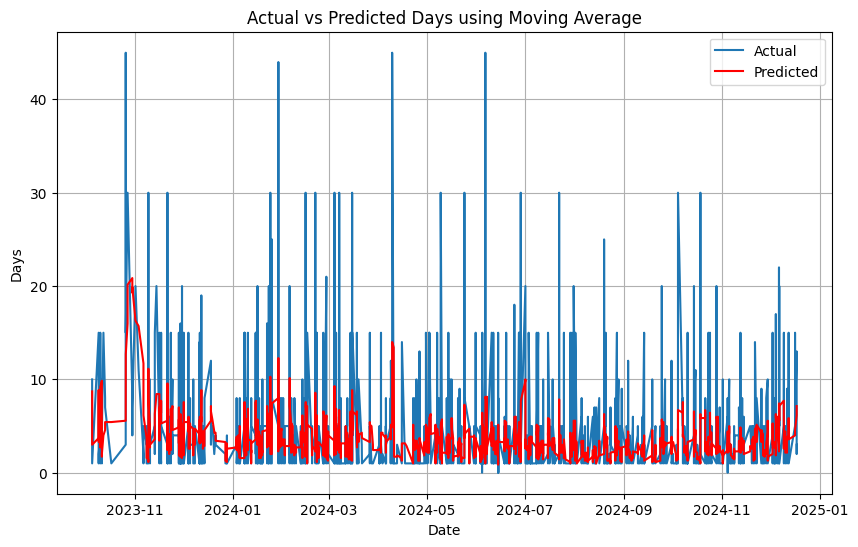

In [39]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

# Read the CSV file into a DataFrame
leave_df = pd.read_csv('./datasets/leave_df.csv')

# Convert the 'submitted_on' column to datetime
leave_df['submitted_on'] = pd.to_datetime(leave_df['submitted_on'])

# Set the 'submitted_on' column as the index
leave_df.set_index('submitted_on', inplace=True)

# Extract the target variable
y = leave_df['days']

# Define the window size for the moving average
window_size = 7

# Calculate the moving average
y_pred = y.rolling(window=window_size).mean()

# Drop the NaN values that result from the moving average calculation
y_pred = y_pred.dropna()

# Align the test set with the moving average predictions
test = y.iloc[window_size-1:]

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(test, y_pred)
print(f'Mean Squared Error: {mse}')

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual')
plt.plot(y_pred.index, y_pred, label='Predicted', color='red')
plt.xlabel('Date')
plt.ylabel('Days')
plt.title('Actual vs Predicted Days using Moving Average')
plt.legend()
plt.grid(True)
plt.show()

# Transformer

/home/peka/prototypes/.venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [10/100], Loss: 0.0019
Epoch [20/100], Loss: 0.0237
Epoch [30/100], Loss: 0.0018
Epoch [40/100], Loss: 0.0025
Epoch [50/100], Loss: 0.0020
Epoch [60/100], Loss: 0.0008
Epoch [70/100], Loss: 0.0078
Epoch [80/100], Loss: 0.0023
Epoch [90/100], Loss: 0.0018
Epoch [100/100], Loss: 0.0049
Mean Squared Error: 16.836095809936523


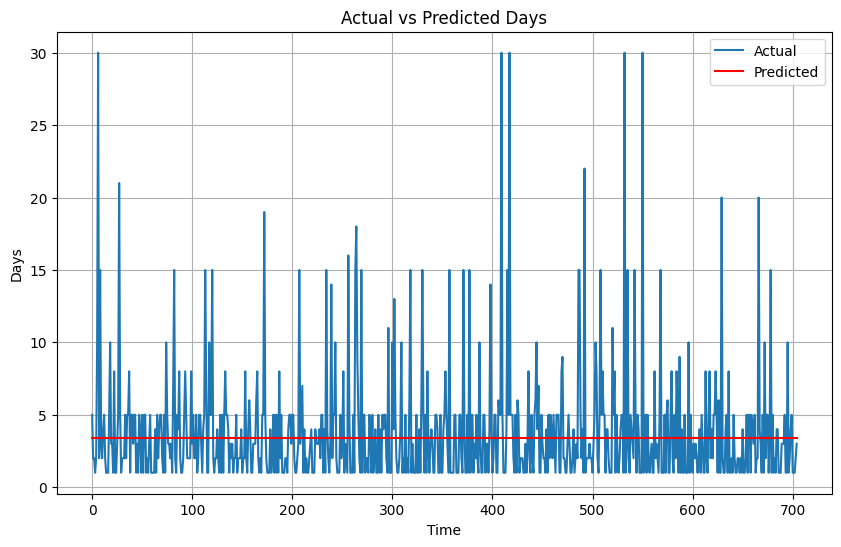

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import BertModel, BertTokenizer, BertConfig, Trainer, TrainingArguments

# Read the CSV file into a DataFrame
leave_df = pd.read_csv('./datasets/leave_df.csv')

# Convert the 'submitted_on' column to datetime
leave_df['submitted_on'] = pd.to_datetime(leave_df['submitted_on'])

# Extract features and target variable
leave_df['month'] = leave_df['submitted_on'].dt.month
leave_df['year'] = leave_df['submitted_on'].dt.year
X = leave_df[['year', 'month']]
y = leave_df['days']

# Normalize the target variable
scaler = MinMaxScaler()
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Define a custom dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train_tensor, y_train_tensor)
test_dataset = TimeSeriesDataset(X_test_tensor, y_test_tensor)

# Define the Transformer model
class TransformerModel(nn.Module):
    def __init__(self, input_dim, model_dim, num_heads, num_layers, output_dim):
        super(TransformerModel, self).__init__()
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(model_dim, output_dim)

    def forward(self, src):
        src = src.unsqueeze(1)  # Add batch dimension
        output = self.transformer_encoder(src)
        output = self.fc(output[:, -1, :])
        return output

# Hyperparameters
input_dim = X_train_tensor.shape[1]
model_dim = 2
num_heads = 2
num_layers = 2
output_dim = 1
num_epochs = 100
learning_rate = 0.001
batch_size = 32

# Initialize the model, loss function, and optimizer
model = TransformerModel(input_dim, model_dim, num_heads, num_layers, output_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Train the model
for epoch in range(num_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model
model.eval()
y_pred = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs = model(X_batch)
        y_pred.extend(outputs.numpy())

y_pred = np.array(y_pred)
y_test = y_test_tensor.numpy()

# Inverse transform the predictions
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted', color='red')
plt.xlabel('Time')
plt.ylabel('Days')
plt.title('Actual vs Predicted Days')
plt.legend()
plt.grid(True)
plt.show()

# Clustering

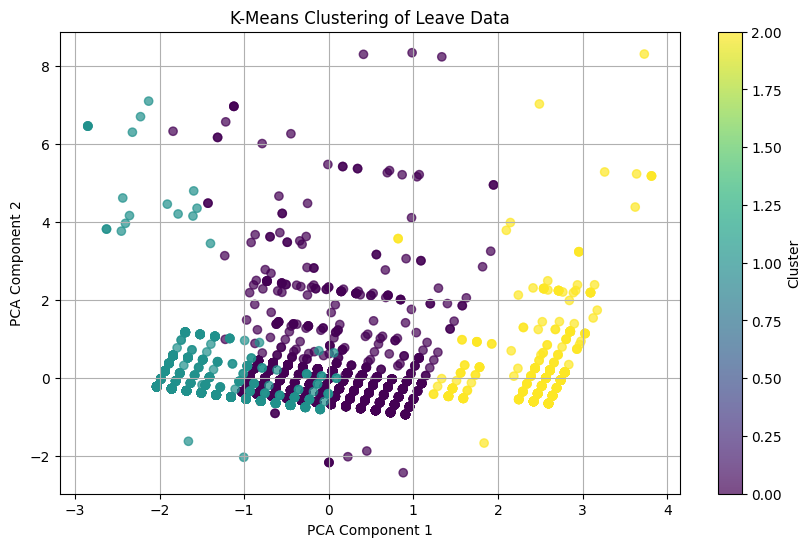

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Read the CSV file into a DataFrame
leave_df = pd.read_csv('./datasets/leave_df.csv')

# Convert the 'submitted_on' column to datetime
leave_df['submitted_on'] = pd.to_datetime(leave_df['submitted_on'])

# Extract features for clustering
leave_df['month'] = leave_df['submitted_on'].dt.month
leave_df['year'] = leave_df['submitted_on'].dt.year
features = leave_df[['year', 'month', 'days', 'type', 'status']]

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
leave_df['cluster'] = kmeans.fit_predict(features_scaled)

# Visualize the clusters using PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(features_scaled)
leave_df['pca1'] = principal_components[:, 0]
leave_df['pca2'] = principal_components[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(leave_df['pca1'], leave_df['pca2'], c=leave_df['cluster'], cmap='viridis', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering of Leave Data')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

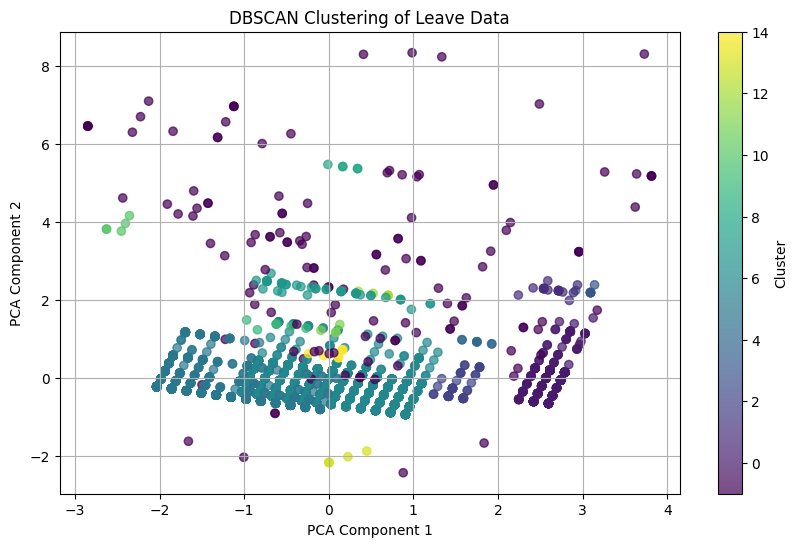

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# Read the CSV file into a DataFrame
leave_df = pd.read_csv('./datasets/leave_df.csv')

# Convert the 'submitted_on' column to datetime
leave_df['submitted_on'] = pd.to_datetime(leave_df['submitted_on'])

# Extract features for clustering
leave_df['month'] = leave_df['submitted_on'].dt.month
leave_df['year'] = leave_df['submitted_on'].dt.year
features = leave_df[['year', 'month', 'days', 'type', 'status']]

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
leave_df['cluster'] = dbscan.fit_predict(features_scaled)

# Visualize the clusters using PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(features_scaled)
leave_df['pca1'] = principal_components[:, 0]
leave_df['pca2'] = principal_components[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(leave_df['pca1'], leave_df['pca2'], c=leave_df['cluster'], cmap='viridis', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('DBSCAN Clustering of Leave Data')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()